# 05 — Supervised Learning

This notebook trains three model families (Linear Regression, Random Forest, XGBoost) 
to predict next-season injury report count from player stats and history.

**Inputs:** `train.csv` (1,620 rows) and `test.csv` (412 rows) from NB04  
**Target:** `target_next_season` (injury report count for the following season)  
**Evaluation:** 5-fold CV on training set, final evaluation on held-out test set

In [7]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.dummy import DummyRegressor

import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# === Configuration ===
PROCESSED_DIR = '../data/processed'
TARGET = 'target_next_season'
RANDOM_STATE = 42

Let's load our traning/test split data, we should have 1,620 train / 412 test, 15 features each. 

In [8]:
# Load train and test sets from NB04
train_df = pd.read_csv(f'{PROCESSED_DIR}/train.csv')
test_df = pd.read_csv(f'{PROCESSED_DIR}/test.csv')

# Separate features and target
X_train = train_df.drop(columns=[TARGET])
y_train = train_df[TARGET]
X_test = test_df.drop(columns=[TARGET])
y_test = test_df[TARGET]

print(f"Train: {X_train.shape[0]:,} rows, {X_train.shape[1]} features")
print(f"Test:  {X_test.shape[0]:,} rows, {X_test.shape[1]} features")
print(f"\nFeatures: {X_train.columns.tolist()}")
print(f"\nTarget distribution (train): mean={y_train.mean():.2f}, median={y_train.median():.1f}, max={y_train.max()}")

assert X_train.shape == (1620, 15), f"Expected (1620, 15), got {X_train.shape}"
assert X_test.shape == (412, 15), f"Expected (412, 15), got {X_test.shape}"

Train: 1,620 rows, 15 features
Test:  412 rows, 15 features

Features: ['min', 'gp', 'dist_miles', 'usg_pct', 'ts_pct', 'age', 'player_height_inches', 'player_weight', 'injured_last_season', 'injury_report_count_last_season', 'b2b_games', 'age_x_minutes', 'weight_x_minutes', 'b2b_x_minutes', 'age_x_weight']

Target distribution (train): mean=1.41, median=1.0, max=11


## 5.3 Baseline Model

Before training any real models, we need a "do nothing" benchmark to compare against.

The baseline simply predicts the training set's mean injury count for every player. 
If our models can't beat this, they haven't learned anything useful from the features.

We track three metrics:
- **MAE** (Mean Absolute Error): average prediction error in injury report counts
- **RMSE** (Root Mean Squared Error): penalizes large misses more heavily
- **R²**: proportion of variance explained (baseline should be ~0.0 by definition)

In [9]:
# Baseline: always predict the training set mean
baseline = DummyRegressor(strategy='mean')
baseline.fit(X_train, y_train)

y_pred_base = baseline.predict(X_test)

print(f"Baseline (predict mean = {y_train.mean():.3f})")
print(f"  MAE:  {mean_absolute_error(y_test, y_pred_base):.3f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_base)):.3f}")
print(f"  R²:   {r2_score(y_test, y_pred_base):.3f}")

Baseline (predict mean = 1.413)
  MAE:  1.048
  RMSE: 1.250
  R²:   -0.032


## 5.4 Linear Regression

Our first model: Linear regression assumes a straight-line relationship between 
each feature and the target. It won't help with complex features but it's 
interpretable and gives us a floor for what a "real" model can do.

We evaluate with 5-fold cross-validation on the training set,
then score on the held-out test set.

In [10]:
# Linear Regression with 5-fold CV
lr = LinearRegression()

# Cross-validation on training set (negative MAE — sklearn convention)
lr_cv_scores = cross_val_score(lr, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')
lr_cv_mae = -lr_cv_scores

print("Linear Regression — 5-Fold CV (train):")
print(f"  MAE per fold: {lr_cv_mae.round(3)}")
print(f"  MAE mean ± std: {lr_cv_mae.mean():.3f} ± {lr_cv_mae.std():.3f}")

# Fit on full training set, evaluate on test
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print(f"\nTest set results:")
print(f"  MAE:  {mean_absolute_error(y_test, y_pred_lr):.3f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_lr)):.3f}")
print(f"  R²:   {r2_score(y_test, y_pred_lr):.3f}")

Linear Regression — 5-Fold CV (train):
  MAE per fold: [1.176 1.344 1.163 1.08  1.024]
  MAE mean ± std: 1.158 ± 0.109

Test set results:
  MAE:  0.928
  RMSE: 1.172
  R²:   0.093


### Linear Regression vs Baseline

| Metric | Baseline | Linear Regression | Improvement |
|--------|----------|-------------------|-------------|
| MAE    | 1.048    | 0.928             | ↓ 11.5%     |
| RMSE   | 1.250    | 1.172             | ↓ 6.2%      |
| R²     | -0.032   | 0.093             | ↑ 0.125     |

Linear regression provides a modest improvement over always predicting the mean. 
R² of 0.09 means the model explains ~9% of the variance in next-season injury counts which isn't 
not strong, but expected given the weak individual feature correlations found in EDA.

## 5.5 Random Forest

Tree-based ensemble that can capture non-linear relationships and feature interactions 
automatically. We start with a default model, then tune hyperparameters.

In [11]:
# Random Forest — default first, then tune
rf_default = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE)

rf_cv_scores = cross_val_score(rf_default, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')
rf_cv_mae = -rf_cv_scores

print("Random Forest (default) — 5-Fold CV (train):")
print(f"  MAE per fold: {rf_cv_mae.round(3)}")
print(f"  MAE mean ± std: {rf_cv_mae.mean():.3f} ± {rf_cv_mae.std():.3f}")

# Test set
rf_default.fit(X_train, y_train)
y_pred_rf = rf_default.predict(X_test)

print(f"\nTest set results:")
print(f"  MAE:  {mean_absolute_error(y_test, y_pred_rf):.3f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_rf)):.3f}")
print(f"  R²:   {r2_score(y_test, y_pred_rf):.3f}")

Random Forest (default) — 5-Fold CV (train):
  MAE per fold: [1.258 1.367 1.164 1.082 1.091]
  MAE mean ± std: 1.193 ± 0.108

Test set results:
  MAE:  1.006
  RMSE: 1.248
  R²:   -0.028


Default Random Forest is actually **worse** than Linear Regression (MAE 1.006 vs 0.928). Let's see if tuning with help.

### Random Forest — Hyperparameter Tuning

Default RF overfits, deep trees memorize noise in the training data instead of learning 
generalizable patterns. We use GridSearchCV to find a better balance by controlling tree 
depth, minimum samples per leaf, and number of trees.

36 parameter combinations × 5 folds

In [12]:
# Grid search over key hyperparameters
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 10, None],
    'min_samples_leaf': [5, 10, 20],
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE),
    param_grid,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)
rf_grid.fit(X_train, y_train)

print(f"Best params: {rf_grid.best_params_}")
print(f"Best CV MAE: {-rf_grid.best_score_:.3f}")

# Test set with best model
y_pred_rf_tuned = rf_grid.best_estimator_.predict(X_test)

print(f"\nTuned RF — Test set results:")
print(f"  MAE:  {mean_absolute_error(y_test, y_pred_rf_tuned):.3f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_rf_tuned)):.3f}")
print(f"  R²:   {r2_score(y_test, y_pred_rf_tuned):.3f}")

Best params: {'max_depth': 5, 'min_samples_leaf': 10, 'n_estimators': 200}
Best CV MAE: 1.142

Tuned RF — Test set results:
  MAE:  0.964
  RMSE: 1.211
  R²:   0.033


Tuning helped (MAE 1.006 → 0.964) but still behind Linear Regression. Let's see if XGBoost can help

## 5.6 XGBoost

Gradient boosting builds trees sequentially: each tree corrects the previous one's errors. 
XGBoost adds regularization to prevent overfitting, which may help given our noisy target.

In [13]:
# XGBoost — default first
xgb_default = XGBRegressor(n_estimators=100, random_state=RANDOM_STATE, verbosity=0)

xgb_cv_scores = cross_val_score(xgb_default, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')
xgb_cv_mae = -xgb_cv_scores

print("XGBoost (default) — 5-Fold CV (train):")
print(f"  MAE per fold: {xgb_cv_mae.round(3)}")
print(f"  MAE mean ± std: {xgb_cv_mae.mean():.3f} ± {xgb_cv_mae.std():.3f}")

# Test set
xgb_default.fit(X_train, y_train)
y_pred_xgb = xgb_default.predict(X_test)

print(f"\nTest set results:")
print(f"  MAE:  {mean_absolute_error(y_test, y_pred_xgb):.3f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_xgb)):.3f}")
print(f"  R²:   {r2_score(y_test, y_pred_xgb):.3f}")

XGBoost (default) — 5-Fold CV (train):
  MAE per fold: [1.309 1.499 1.236 1.16  1.154]
  MAE mean ± std: 1.271 ± 0.127

Test set results:
  MAE:  1.068
  RMSE: 1.374
  R²:   -0.246


Default XGBoost overfits significantly. We add regularization (learning rate, max depth, 
subsample) to slow down learning and prevent memorizing noise.

In [14]:
# Regularizations

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [2, 3, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
}

xgb_grid = GridSearchCV(
    XGBRegressor(random_state=RANDOM_STATE, verbosity=0),
    param_grid,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)
xgb_grid.fit(X_train, y_train)

print(f"Best params: {xgb_grid.best_params_}")
print(f"Best CV MAE: {-xgb_grid.best_score_:.3f}")

# Test set with best model
y_pred_xgb_tuned = xgb_grid.best_estimator_.predict(X_test)

print(f"\nTuned XGBoost — Test set results:")
print(f"  MAE:  {mean_absolute_error(y_test, y_pred_xgb_tuned):.3f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_xgb_tuned)):.3f}")
print(f"  R²:   {r2_score(y_test, y_pred_xgb_tuned):.3f}")

Best params: {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 200, 'subsample': 0.8}
Best CV MAE: 1.130

Tuned XGBoost — Test set results:
  MAE:  0.941
  RMSE: 1.189
  R²:   0.067


Tuning helped massively (MAE 1.068 → 0.941). XGBoost is now our best model.

## 5.7 Overall Results Comparison

Summary of all models on the held-out test set (2017-18 → 2018-19 predictions).

In [15]:
results = pd.DataFrame({
    'Model': ['Baseline (Mean)', 'Linear Regression', 'Random Forest (tuned)', 'XGBoost (tuned)'],
    'CV MAE (mean ± std)': [
        'N/A',
        f"{lr_cv_mae.mean():.3f} ± {lr_cv_mae.std():.3f}",
        f"{-rf_grid.best_score_:.3f} ± {rf_grid.cv_results_['std_test_score'][rf_grid.best_index_]:.3f}",
        f"{-xgb_grid.best_score_:.3f} ± {xgb_grid.cv_results_['std_test_score'][xgb_grid.best_index_]:.3f}",
    ],
    'Test MAE': [
        mean_absolute_error(y_test, y_pred_base),
        mean_absolute_error(y_test, y_pred_lr),
        mean_absolute_error(y_test, y_pred_rf_tuned),
        mean_absolute_error(y_test, y_pred_xgb_tuned),
    ],
    'Test RMSE': [
        np.sqrt(mean_squared_error(y_test, y_pred_base)),
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf_tuned)),
        np.sqrt(mean_squared_error(y_test, y_pred_xgb_tuned)),
    ],
    'Test R²': [
        r2_score(y_test, y_pred_base),
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_rf_tuned),
        r2_score(y_test, y_pred_xgb_tuned),
    ]
})

results['Test MAE'] = results['Test MAE'].round(3)
results['Test RMSE'] = results['Test RMSE'].round(3)
results['Test R²'] = results['Test R²'].round(3)

print(results.to_string(index=False))

                Model CV MAE (mean ± std)  Test MAE  Test RMSE  Test R²
      Baseline (Mean)                 N/A     1.048      1.250   -0.032
    Linear Regression       1.158 ± 0.109     0.928      1.172    0.093
Random Forest (tuned)       1.142 ± 0.109     0.964      1.211    0.033
      XGBoost (tuned)       1.130 ± 0.113     0.941      1.189    0.067


## 5.8 Feature Importance (XGBoost)

Which features contribute most to predictions? We use XGBoost's built-in feature 
importance (based on how often and how much each feature improves splits).

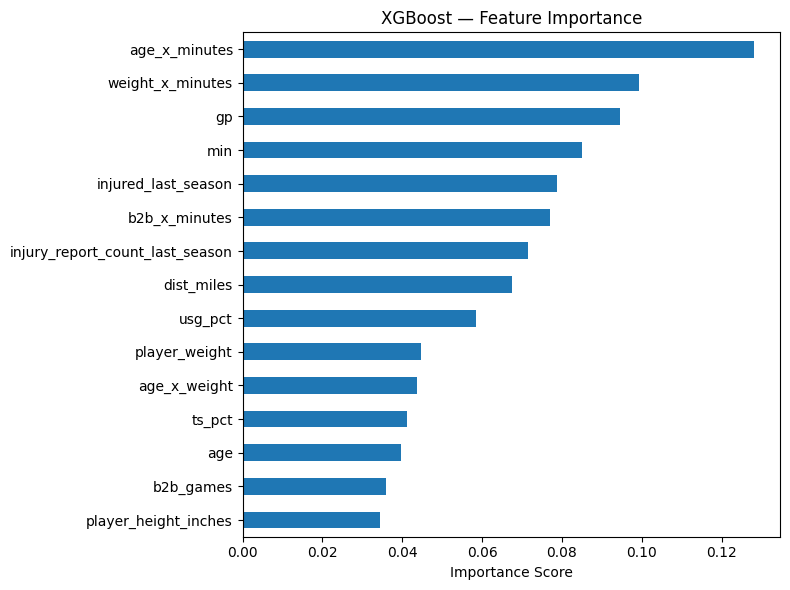


Feature importance (sorted):
  age_x_minutes                       0.1282
  weight_x_minutes                    0.0994
  gp                                  0.0944
  min                                 0.0851
  injured_last_season                 0.0788
  b2b_x_minutes                       0.0770
  injury_report_count_last_season     0.0714
  dist_miles                          0.0675
  usg_pct                             0.0585
  player_weight                       0.0447
  age_x_weight                        0.0436
  ts_pct                              0.0412
  age                                 0.0398
  b2b_games                           0.0360
  player_height_inches                0.0344


In [16]:
best_xgb = xgb_grid.best_estimator_

# Feature importance
importance = pd.Series(best_xgb.feature_importances_, index=X_train.columns)
importance = importance.sort_values(ascending=True)

plt.figure(figsize=(8, 6))
importance.plot(kind='barh')
plt.title('XGBoost — Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\nFeature importance (sorted):")
for feat, imp in importance.sort_values(ascending=False).items():
    print(f"  {feat:35s} {imp:.4f}")

Interesting to see **age_x_minutes** leads, and the interaction features collectively are quite important. **Injury history** (injured_last_season + injury_report_count_last_season) is mid-tier individually but strong together. 

## 5.9 Ablation Analysis

Ablation = remove a group of features, retrain the model, see if performance gets worse.

- If MAE goes **up** → those features were helping (the model needs them)
- If MAE stays the **same** → those features weren't contributing much

Let's remove one group at a time to find out which groups matter most.

In [17]:
# Define feature groups
feature_groups = {
    'Workload':         ['min', 'gp', 'dist_miles', 'usg_pct', 'ts_pct'],
    'Physical':         ['age', 'player_height_inches', 'player_weight'],
    'Injury History':   ['injured_last_season', 'injury_report_count_last_season'],
    'Team Context':     ['b2b_games'],
    'Interactions':     ['age_x_minutes', 'weight_x_minutes', 'b2b_x_minutes', 'age_x_weight'],
}

# Baseline: full model MAE
full_mae = mean_absolute_error(y_test, y_pred_xgb_tuned)
print(f"Full model MAE: {full_mae:.3f}\n")

ablation_results = []
best_params = xgb_grid.best_params_

for group_name, group_features in feature_groups.items():
    # Remove this group
    remaining = [f for f in X_train.columns if f not in group_features]
    
    model = XGBRegressor(**best_params, random_state=RANDOM_STATE, verbosity=0)
    model.fit(X_train[remaining], y_train)
    y_pred = model.predict(X_test[remaining])
    
    ablated_mae = mean_absolute_error(y_test, y_pred)
    impact = ablated_mae - full_mae
    
    ablation_results.append({
        'Removed Group': group_name,
        'Features Removed': len(group_features),
        'MAE Without': round(ablated_mae, 3),
        'MAE Impact': round(impact, 3),
    })

ablation_df = pd.DataFrame(ablation_results).sort_values('MAE Impact', ascending=False)
print(ablation_df.to_string(index=False))

Full model MAE: 0.941

 Removed Group  Features Removed  MAE Without  MAE Impact
Injury History                 2        0.956       0.015
  Team Context                 1        0.954       0.013
  Interactions                 4        0.954       0.013
      Physical                 3        0.948       0.007
      Workload                 5        0.925      -0.016


**Takeaways from the ablation analysis:**

Injury History (+0.015): Removing prior injury info hurts the model the most. Makes sense — knowing if someone was injured before is the best predictor of future injury. This matches what we found in EDA (2x more likely).

Team Context (+0.013) and Interactions (+0.013): B2B games and the interaction features each contribute modestly. Removing them makes the model slightly worse.

Physical (+0.007): Age, height, weight barely matter on their own. The model doesn't lose much without them.

Workload (-0.016): This is the surprise. Removing minutes, games played, distance, usage rate, and true shooting improved the model.

This means those features are adding more noise than signal: the model is slightly better off without them. 

## 5.10 Sensitivity Analysis

Now let's see how sensitive is our best model (XGBoost) to its hyperparameters? We vary one parameter 
at a time while keeping the others at their tuned values, and measure the effect on test MAE.

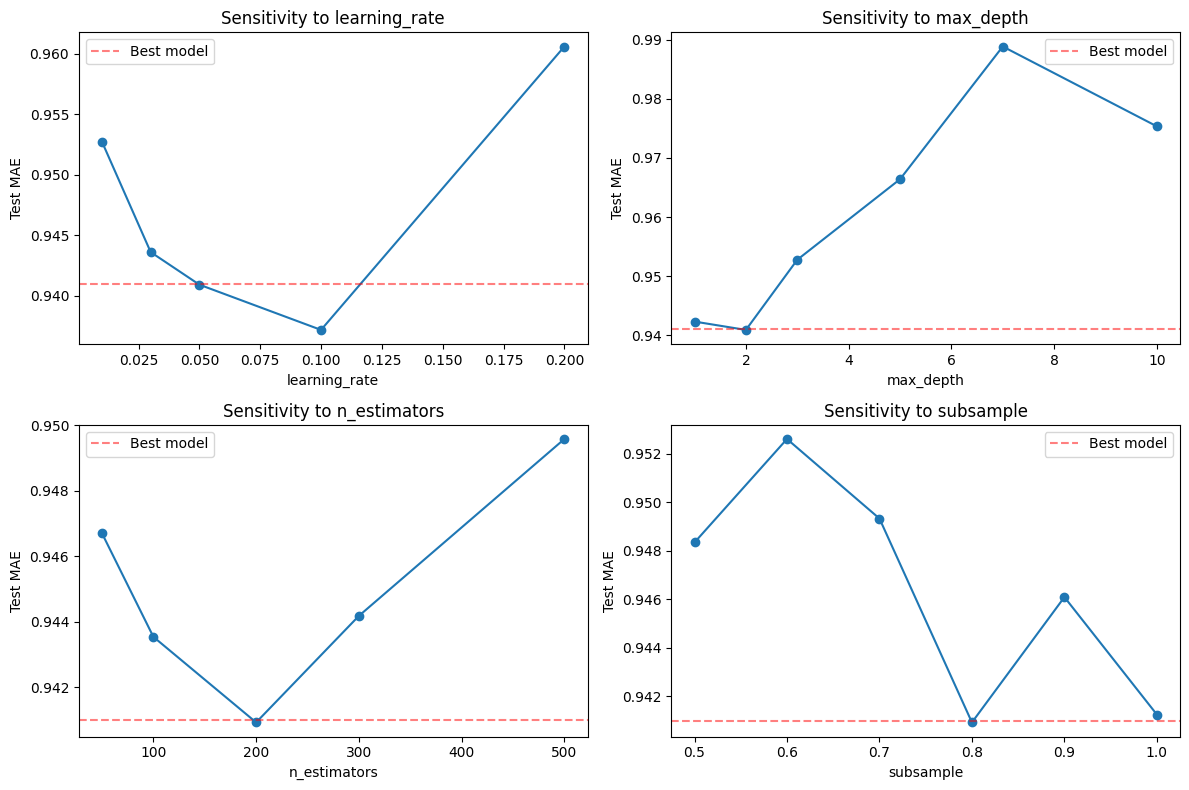

In [18]:
best = xgb_grid.best_params_  # {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 200, 'subsample': 0.8}

sensitivity_tests = {
    'learning_rate': [0.01, 0.03, 0.05, 0.1, 0.2],
    'max_depth': [1, 2, 3, 5, 7, 10],
    'n_estimators': [50, 100, 200, 300, 500],
    'subsample': [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for idx, (param, values) in enumerate(sensitivity_tests.items()):
    maes = []
    for val in values:
        params = best.copy()
        params[param] = val
        model = XGBRegressor(**params, random_state=RANDOM_STATE, verbosity=0)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        maes.append(mean_absolute_error(y_test, y_pred))
    
    axes[idx].plot(values, maes, 'o-')
    axes[idx].axhline(y=0.941, color='r', linestyle='--', alpha=0.5, label='Best model')
    axes[idx].set_xlabel(param)
    axes[idx].set_ylabel('Test MAE')
    axes[idx].set_title(f'Sensitivity to {param}')
    axes[idx].legend()

plt.tight_layout()
plt.show()

### Sensitivity Analysis Takeaways

**max_depth is the most sensitive parameter.** Going from 2 to 7 increases MAE by ~0.05  

**learning_rate has a sweet spot around 0.05–0.1.** Too slow (0.01) underfits, too fast (0.2) overfits.

**n_estimators and subsample are relatively stable.** The model isn't very sensitive to these:
our tuned values (200 trees, 0.8 subsample) sit near the optimum but nearby values perform similarly.

The model is most sensitive to tree depth, reinforcing that the injury prediction 
signal is weak and models that try to learn complex patterns overfit. Simple, shallow models generalize best.

## 5.11 Failure Analysis

Let's examine specific players where the model's prediction was most wrong, and categorize 
the types of failures. This helps us understand the model's limitations.

In [19]:
# Build failure analysis dataframe
test_analysis = test_df.copy()
test_analysis['predicted'] = y_pred_xgb_tuned
test_analysis['error'] = test_analysis['predicted'] - test_analysis[TARGET]
test_analysis['abs_error'] = test_analysis['error'].abs()

# Top 10 worst predictions
worst = test_analysis.nlargest(10, 'abs_error')
print("Top 10 Worst Predictions:")
print(worst[['min', 'gp', 'age', 'injured_last_season', 'injury_report_count_last_season',
             TARGET, 'predicted', 'error']].to_string(index=False))

Top 10 Worst Predictions:
 min  gp  age  injured_last_season  injury_report_count_last_season  target_next_season  predicted     error
36.4  75 25.0                  1.0                              3.0                   7   2.088427 -4.911573
18.3  81 31.0                  1.0                              3.0                   5   0.990270 -4.009730
16.8  25 29.0                  1.0                              4.0                   5   1.012937 -3.987063
12.3  20 21.0                  0.0                              0.0                   4   0.529381 -3.470619
12.1  73 24.0                  1.0                              1.0                   4   0.815591 -3.184409
29.9  73 31.0                  1.0                              3.0                   5   2.046504 -2.953496
14.0  53 30.0                  1.0                              3.0                   4   1.211215 -2.788785
14.4  32 28.0                  1.0                              3.0                   4   1.212435 -2.

All errors are negative: the model consistently underpredicts high-injury players. Let's categorize:

In [20]:
# Categorize failure types
print("\n=== Failure Category 1: Healthy profile, sudden spike ===")
print("Players with NO prior injury history who got 4+ injuries next season")
cat1 = worst[(worst['injured_last_season'] == 0) & (worst['injury_report_count_last_season'] == 0)]
print(f"Count: {len(cat1)}")
print(cat1[['min', 'gp', 'age', 'injured_last_season', TARGET, 'predicted', 'error']].to_string(index=False))

print("\n=== Failure Category 2: Known risk, but severity underestimated ===")
print("Players WITH prior injuries, but actual outcome far exceeded prediction")
cat2 = worst[(worst['injured_last_season'] == 1) & (worst[TARGET] >= 5)]
print(f"Count: {len(cat2)}")
print(cat2[['min', 'gp', 'age', 'injury_report_count_last_season', TARGET, 'predicted', 'error']].to_string(index=False))

print("\n=== Failure Category 3: Moderate history, moderate undershoot ===")
print("Prior injuries, target = 4, model predicted ~1")
cat3 = worst[(worst['injured_last_season'] == 1) & (worst[TARGET] == 4)]
print(f"Count: {len(cat3)}")
print(cat3[['min', 'gp', 'age', 'injury_report_count_last_season', TARGET, 'predicted', 'error']].to_string(index=False))


=== Failure Category 1: Healthy profile, sudden spike ===
Players with NO prior injury history who got 4+ injuries next season
Count: 2
 min  gp  age  injured_last_season  target_next_season  predicted     error
12.3  20 21.0                  0.0                   4   0.529381 -3.470619
23.2  63 23.0                  0.0                   4   1.231610 -2.768390

=== Failure Category 2: Known risk, but severity underestimated ===
Players WITH prior injuries, but actual outcome far exceeded prediction
Count: 4
 min  gp  age  injury_report_count_last_season  target_next_season  predicted     error
36.4  75 25.0                              3.0                   7   2.088427 -4.911573
18.3  81 31.0                              3.0                   5   0.990270 -4.009730
16.8  25 29.0                              4.0                   5   1.012937 -3.987063
29.9  73 31.0                              3.0                   5   2.046504 -2.953496

=== Failure Category 3: Moderate history, mo

### Failure Analysis Takeaways

All top failures are **underpredictions** — the model can't anticipate high-injury seasons.

**Category 1 — Sudden spike (2 cases):** Young, healthy players with zero injury history 
who suddenly had 4 injuries. The model has no signal to predict these.

**Category 2 — Severity underestimated (4 cases):** Players with 3–4 prior injuries who 
had 5–7 next season. The model knows they're at-risk but predicts ~2 instead of 5+.

**Category 3 — Moderate undershoot (4 cases):** Some injury history, target = 4, model 
predicts ~1.2. These are the most "fixable" with better features.

**Root cause:** The target is zero-inflated (50.7% zeros), so the model learns to predict 
low. Extreme injury seasons are rare and hard to learn from.

**Possible improvements (not implemented):** injury type features, workload trends 
across seasons, or reframing as classification (injured yes/no).

## 5.12 Summary & Handoff to NB06

**Best model:** XGBoost (MAE: 0.941, R²: 0.067) — modestly beats baseline (MAE: 1.048).

**Key findings:**

- Injury prediction is inherently difficult — all models only slightly beat predicting the mean

- Shallow, regularized models work best; deep trees overfit

- Prior injury history is the most important feature group

- Model underpredicts high-injury players due to zero-inflated target

**Next:** NB06 — Unsupervised clustering for player injury risk archetypes.